<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import all the required libraries

---



In [1]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

# Define start day to fetch the dataset from the yahoo finance library

---



In [2]:


START = "2015-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [3]:
data = load_data('AAPL')
df=data
df.head()

/tmp/ipython-input-3830313737.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START, TODAY)
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.237556,24.705326,23.798606,24.694241,212818400
1,2015-01-05,23.554739,24.086799,23.368519,24.006990,257142000
2,2015-01-06,23.556957,23.816336,23.195599,23.619031,263188400
3,2015-01-07,23.887281,23.987042,23.654504,23.765350,160423600
4,2015-01-08,24.805082,24.862723,24.097885,24.215383,237458000


In [5]:
df = df.drop(['Date'], axis = 1)
df.head()

/tmp/ipython-input-3502562368.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.237556,24.705326,23.798606,24.694241,212818400
1,23.554739,24.086799,23.368519,24.006990,257142000
2,23.556957,23.816336,23.195599,23.619031,263188400
3,23.887281,23.987042,23.654504,23.765350,160423600
4,24.805082,24.862723,24.097885,24.215383,237458000


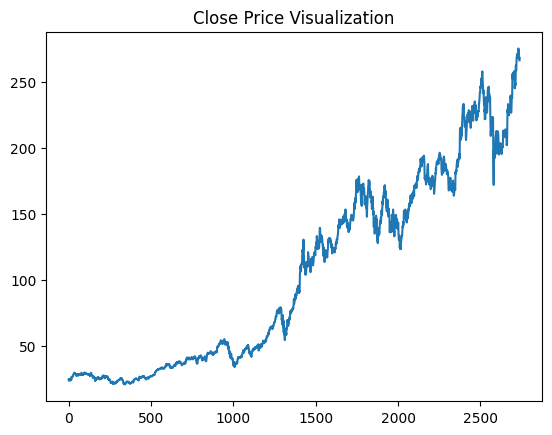

In [6]:
plt.title("Close Price Visualization")
plt.plot(df.Close)

In [7]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,24.237556,24.705326,23.798606,24.694241,212818400
1,23.554739,24.086799,23.368519,24.006990,257142000
2,23.556957,23.816336,23.195599,23.619031,263188400
3,23.887281,23.987042,23.654504,23.765350,160423600
4,24.805082,24.862723,24.097885,24.215383,237458000
...,...,...,...,...,...
2734,272.410004,275.959991,269.600006,271.049988,47431300
2735,267.459991,270.489990,265.730011,268.820007,45018300
2736,267.440002,270.709991,265.320007,269.989990,45677300


# Plotting moving averages of 100 day

---



In [8]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2734,236.879599
2735,237.548421
2736,238.216246
2737,238.854457


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

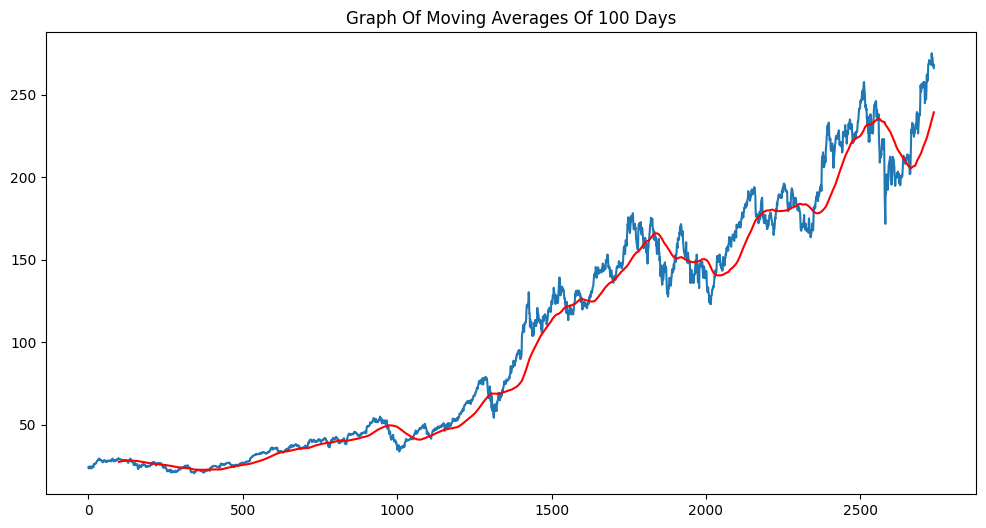

In [9]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.title('Graph Of Moving Averages Of 100 Days')

# Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

---



In [10]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2734,224.900103
2735,225.062715
2736,225.264998
2737,225.449039


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

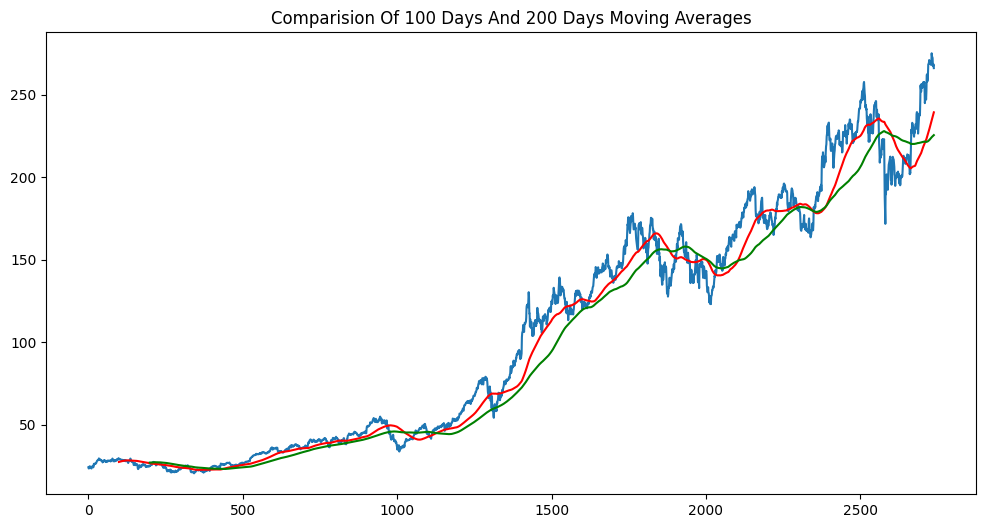

In [11]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [12]:
df.shape

(2739, 5)

# Spliting the dataset into training (70%) and testing (30%) set

In [13]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(1917, 6)
(822, 6)


In [14]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.237556,24.705326,23.798606,24.694241,212818400
1,2015-01-05,23.554739,24.086799,23.368519,24.006990,257142000
2,2015-01-06,23.556957,23.816336,23.195599,23.619031,263188400
3,2015-01-07,23.887281,23.987042,23.654504,23.765350,160423600
4,2015-01-08,24.805082,24.862723,24.097885,24.215383,237458000


In [15]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
1917,2022-08-15,170.333481,170.530179,168.523833,168.691027,54091700
1918,2022-08-16,170.176132,170.844924,168.828733,169.930256,56377100
1919,2022-08-17,171.671036,173.244637,169.723697,169.920396,79542000
1920,2022-08-18,171.277634,172.015263,170.264623,170.884237,62290100
1921,2022-08-19,168.691010,170.874395,168.484467,170.176099,70346300


# Using MinMax scaler for normalization of the dataset

---



In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [35]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [36]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.02631943],
       [0.02197938],
       [0.01952939],
       ...,
       [0.91182095],
       [0.92660301],
       [0.92511227]])

In [37]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [38]:
x_train.shape

(1817, 100, 1)

# ML Model (LSTM)

---



In [39]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [40]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

---



In [33]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['MAE'])
model.fit(x_train, y_train, validation_data = (x_test, y_test) ,epochs = 50)

NameError: name 'x_test' is not defined

In [42]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [43]:
model.save('keras_model.h5')

In [44]:

test_close.shape
test_close

array([[168.6910269 ],
       [169.93025557],
       [169.92039567],
       [170.88423711],
       [170.17609867],
       [166.89122718],
       [164.32425128],
       [164.56033298],
       [165.99621813],
       [167.75672364],
       [158.49205969],
       [159.45589319],
       [157.66592355],
       [154.05646992],
       [157.11512948],
       [153.88926727],
       [152.2664378 ],
       [152.08943851],
       [152.90574263],
       [156.95780504],
       [157.26270593],
       [152.23693981],
       [152.09928154],
       [148.71601439],
       [146.84735622],
       [150.86987663],
       [154.74492033],
       [149.8667165 ],
       [148.69635764],
       [147.19157146],
       [150.22080529],
       [145.20488029],
       [143.69029305],
       [138.94977944],
       [135.93043653],
       [142.63791815],
       [141.69377951],
       [143.40507882],
       [140.18897576],
       [138.10400391],
       [137.59255306],
       [136.83526713],
       [132.76355465],
       [141

In [45]:
past_100_days = pd.DataFrame(train_close[-100:])

In [46]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [48]:
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [ ]:
final_df.head()

,0
0,81.279999
1,80.580002
2,82.875000
3,83.364998
4,85.997498


In [49]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.25021302],
       [0.26615282],
       [0.28588457],
       [0.30400952],
       [0.29301865],
       [0.32206988],
       [0.33402479],
       [0.32946112],
       [0.30497351],
       [0.30844424],
       [0.32727579],
       [0.29423993],
       [0.28652714],
       [0.29051183],
       [0.27078027],
       [0.26634561],
       [0.26229615],
       [0.2830565 ],
       [0.23999351],
       [0.24706383],
       [0.27110184],
       [0.27206564],
       [0.25631887],
       [0.22199726],
       [0.22926013],
       [0.18851129],
       [0.20997842],
       [0.22662503],
       [0.19365333],
       [0.20290835],
       [0.21267778],
       [0.23954411],
       [0.1906273 ],
       [0.18367573],
       [0.18747329],
       [0.17447107],
       [0.1054054 ],
       [0.11712016],
       [0.1232995 ],
       [0.14460502],
       [0.13166694],
       [0.08680347],
       [0.0817182 ],
       [0.07335048],
       [0.09278933],
       [0.07746986],
       [0.07077575],
       [0.122

In [50]:
input_data.shape

(922, 1)

# Testing the model

---



In [51]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [52]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(822, 100, 1)
(822,)


# Making prediction and plotting the graph of predicted vs actual values

---



In [53]:
# Making predictions

y_pred = model.predict(x_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


In [54]:
y_pred.shape

(822, 1)

In [55]:
y_test

array([0.29199423, 0.30011582, 0.3000512 , 0.30636797, 0.30172701,
       0.2801988 , 0.26337549, 0.26492271, 0.27433314, 0.28587104,
       0.22515279, 0.23146951, 0.21973851, 0.19608307, 0.21612874,
       0.19498726, 0.18435165, 0.18319164, 0.18854149, 0.21509768,
       0.21709592, 0.18415833, 0.18325615, 0.16108308, 0.14883637,
       0.17519895, 0.200595  , 0.16862449, 0.16095426, 0.15109227,
       0.1709451 , 0.138072  , 0.12814578, 0.09707766, 0.07728966,
       0.12124879, 0.11506114, 0.12627656, 0.10519904, 0.09153467,
       0.08818275, 0.08321969, 0.05653472, 0.11660814, 0.0957242 ,
       0.12421401, 0.09972061, 0.10829323, 0.10732613, 0.13517162,
       0.15386386, 0.15947175, 0.1408439 , 0.14168179, 0.17365204,
       0.18602782, 0.14651587, 0.10210537, 0.10381788, 0.07166532,
       0.09297146, 0.08063966, 0.09833018, 0.12790038, 0.14823772,
       0.16922066, 0.14927063, 0.1318386 , 0.16980175, 0.15592078,
       0.14281447, 0.15133678, 0.14397625, 0.12350977, 0.11802

In [56]:
y_pred

array([[-0.0005577 ],
       [-0.00057835],
       [-0.00059917],
       [-0.00062007],
       [-0.00064096],
       [-0.00066165],
       [-0.00068198],
       [-0.00070148],
       [-0.00071957],
       [-0.0007359 ],
       [-0.00075036],
       [-0.00076247],
       [-0.00077185],
       [-0.00077815],
       [-0.00078068],
       [-0.00077959],
       [-0.00077502],
       [-0.00076752],
       [-0.0007576 ],
       [-0.00074559],
       [-0.0007321 ],
       [-0.00071778],
       [-0.0007029 ],
       [-0.00068782],
       [-0.00067261],
       [-0.00065719],
       [-0.00064172],
       [-0.00062659],
       [-0.00061196],
       [-0.00059787],
       [-0.00058426],
       [-0.0005712 ],
       [-0.00055861],
       [-0.00054633],
       [-0.00053411],
       [-0.00052156],
       [-0.0005086 ],
       [-0.00049524],
       [-0.00048168],
       [-0.00046799],
       [-0.00045415],
       [-0.00044014],
       [-0.00042595],
       [-0.00041154],
       [-0.00039728],
       [-0

In [57]:
scaler.scale_

array([0.00655375])

In [58]:
scale_factor = 1/0.00985902
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

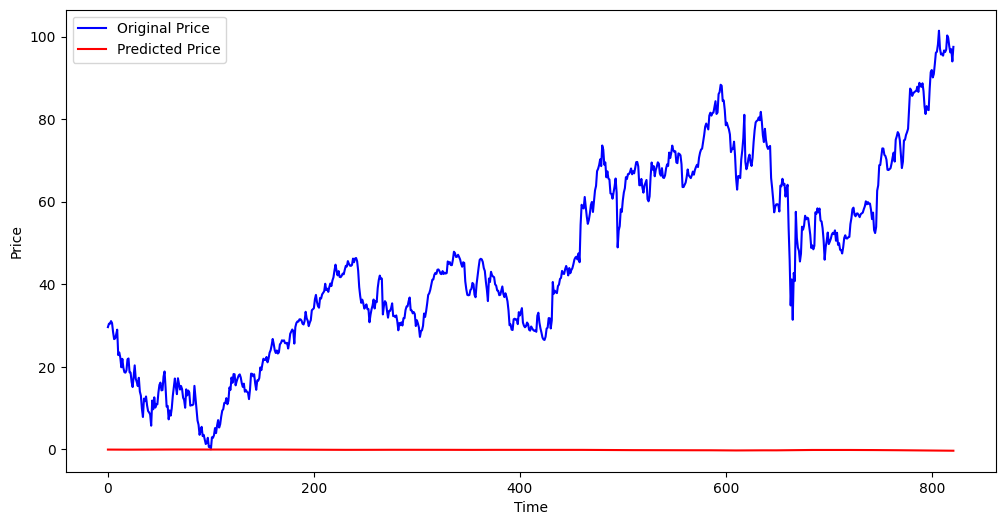

In [59]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Model evaluation

In [60]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean absolute error on test set: ", mae)

Mean absolute error on test set:  46.19637261080139
